In [1]:
import numpy as np
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

%matplotlib inline

In [2]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)

In [3]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.60e+01 4.19e-18 2.90e+01]
 [2.00e+01 3.19e-18 2.90e+01]
 [3.00e+01 1.66e-18 2.90e+01]
 [5.00e+01 3.61e-19 3.30e+01]
 [1.00e+02 5.60e-20 4.70e+01]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.60e+01 3.97e-18 2.90e+01]
 [2.00e+01 3.70e-18 2.90e+01]
 [3.00e+01 4.56e-18 2.90e+01]
 [5.00e+01 5.78e-18 2.90e+01]
 [1.00e+02 3.28e-18 2.90e+01]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.60e+01 6.09e-19 3.30e+01]
 [2.00e+01 6.44e-19 3.30e+01]
 [3.00e+01 4.54e-19 4.70e+01]
 [5.00e+01 1.12e-19 4.70e+01]
 [1.00e+02 5.41e-20 4.70e+01]]
Excitation, level 4
['E', 'crs', 'crs-rms']
[[1.60e+01 8.53e-18 2.90e+01]
 [2.00e+01 1.00e-17 2.90e+01]


In [ ]:
refIdx = 0

# W = [[]]
for k, dataset in enumerate(swarms[refIdx].datasets):
    temp = np.copy(dataset.data)
    temp[:,1] *= 1e-4
    temp[:,2] *= 1e-2 * temp[:,1]
    if (k==0):
        W = np.copy(temp)
    else:
        W = np.append( W, temp, axis=0)

    filename = '../crs-exp/crs.%s.%d.txt' % (refs[refIdx], k+1)
    np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
    
    if(k==3):
        break

plt.figure(1)
plt.errorbar(W[:,0],W[:,1],yerr=W[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

In [ ]:
refIdx = 1

temp = np.copy(swarms[refIdx].datasets[0].data)
error = 0.2 * temp[:,1][...,None]
W = np.append( temp, error, axis=1)

filename = '../crs-exp/crs.%s.1+3.txt' % (refs[refIdx])
np.savetxt(filename,W,fmt='%.15E',delimiter=' ')

plt.figure(1)
plt.errorbar(W[:,0],W[:,1],yerr=W[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

In [ ]:
refIdx = 2

for k, dataset in enumerate(swarms[refIdx].datasets):
    temp = np.copy(dataset.data)
    if (k==0):
        W = np.copy(temp)
    else:
        W = np.append( W, temp, axis=0)

    filename = '../crs-exp/crs.%s.%d.txt' % (refs[refIdx], k+1)
    np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
    
    if(k==3):
        break

plt.figure(1)
plt.errorbar(W[:,0],W[:,1],yerr=W[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

In [ ]:
refIdx = 3

W = np.copy(swarms[refIdx].datasets[0].data)
W[:,1:] *= 1e-4
# W[:,2] *= 3
# W[:,4] *= 3
# W[:,6] *= 3
# W[:,8] *= 3

filename = '../crs-exp/crs.%s.txt' % (refs[refIdx])
np.savetxt(filename,W,fmt='%.15E',delimiter=' ')

plt.figure(1)
for k in range(4):
    plt.errorbar(W[:,0],W[:,2*k+1],yerr=W[:,2*k+2],fmt='.')
plt.xscale('log')
plt.yscale('log')

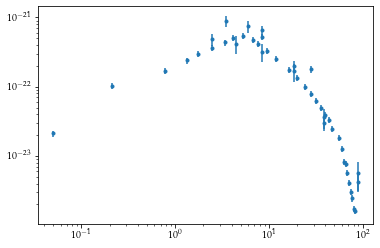

In [100]:
dataType = crs.typeDictS2I['Excitation, level 1']

# W = [[]]
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        temp = np.copy(swarm.datasets[dataType].data)
        var1 = swarm.datasets[dataType].variables[1]

        if ( swarm.variables[var1][0] == 'cm2' ):
            temp[:,1] *= 1e-4
            
        if (swarm.variables[var1][1]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        elif (swarm.variables[var1][2]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 / 3.0 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        else:
            var2 = swarm.datasets[dataType].variables[2]
            if ( swarm.variables[var2][0] == '%' ):
                temp[:,2] *= 1e-2 * temp[:,1]
            elif ( swarm.variables[var2][0] == 'cm2' ):
                temp[:,2] *= 1e-4
            if ( var2[-3:] == 'max' ):
#                 temp[:,2] *= 1.0
                temp[:,2] *= 1.0 / 3.0
                
        if (k==0):
            W = np.copy(temp)
        else:
            W = np.append( W, temp, axis=0)

        filename = '../crs-exp/excitation-level1/crs.%s.txt' % (refs[k])
        np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
    
E1 = 11.55
plt.figure(1)
plt.errorbar(W[:,0]-E1,W[:,1],yerr=W[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

{'var': 9.935857274743235, 'len_scale': 2.164494554955009, 'nugget': 0.49309007212254935}


/opt/homebrew/lib/python3.9/site-packages/gstools/covmodel/plot.py:112: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


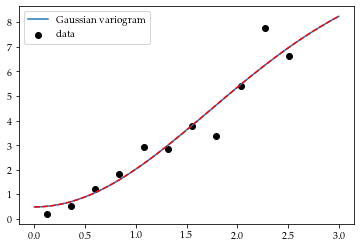

In [152]:
import gstools as gs

Wn = np.copy(W)
E1 = 11.55
Wn[:,0] = np.log(Wn[:,0] - E1)
Wn[:,2] = np.log( 1.0 + Wn[:,2]/Wn[:,1] )
Wn[:,1] = np.log(Wn[:,1])

bins = gs.variogram.standard_bins(Wn[:,0])
bin_center, gamma = gs.vario_estimate(Wn[:,0],Wn[:,1],bin_edges=bins)

models = {
    "Gaussian": gs.Gaussian,
    "Exponential": gs.Exponential,
    "Matern": gs.Matern,
    "Stable": gs.Stable,
    "Rational": gs.Rational,
    "Circular": gs.Circular,
    "Spherical": gs.Spherical,
    "SuperSpherical": gs.SuperSpherical,
    "JBessel": gs.JBessel,
}
scores = {}

# plot the estimated variogram
plt.scatter(bin_center, gamma, color="k", label="data")
ax = plt.gca()

# fit all models to the estimated variogram
# for modelType in models:
modelType = "Gaussian"
fit_model = models[modelType](dim=1)
# fit_model.set_arg_bounds(nugget=[1.0,5.0],len_scale=[0.,3.])
para, pcov, r2 = fit_model.fit_variogram(bin_center, gamma, return_r2=True)
# fit_model.plot(x_max=1, ax=ax)
scores[modelType] = r2
    
print(para)
# fit_model.nugget = 1.0
# fit_model.var *= 0.9
# fit_model.len_scale -= 0.02
para['nugget'] = fit_model.nugget
para['var'] = fit_model.var
fit_model.plot(x_max=3, ax=ax)
model = models[modelType](dim=1, **para)

r = np.linspace(0.,3.0,51)
Z = fit_model.variogram(r)
plt.plot(r,Z,'--r');

filename = '../crs-exp/excitation-level1/krig.variogram.model.txt'
np.savetxt(filename,np.array([r,Z]).T,fmt='%.15E',delimiter=' ')
filename = '../crs-exp/excitation-level1/krig.variogram.empirical.txt'
np.savetxt(filename,np.array([bin_center,gamma]).T,fmt='%.15E',delimiter=' ')

In [153]:
krig = gs.Krige(
    model=model,
    cond_pos=Wn[:,0],
    cond_val=Wn[:,1],
#     mean=1,
#     unbiased=False,
    exact=False,
    cond_err=Wn[:,2],
)

# resulting grid
gridx = np.linspace(np.log(1e-3), np.log(2e2), 101)
krig(gridx)

(array([-53.20189929, -53.23128997, -53.26338244, -53.29807895,
        -53.33519422, -53.3744431 , -53.4154294 , -53.45763641,
        -53.50041999, -53.54300477, -53.58448446, -53.62382677,
        -53.65988367, -53.69140737, -53.7170724 , -53.73550372,
        -53.74531076, -53.74512668, -53.73365208, -53.70970197,
        -53.67225428, -53.62049824, -53.55388037, -53.47214602,
        -53.37537384, -53.2640012 , -53.13883815, -53.00106834,
        -52.85223531, -52.69421352, -52.52916383, -52.35947414,
        -52.18768663, -52.0164138 , -51.84824632, -51.68565656,
        -51.53090187, -51.3859324 , -51.25230809, -51.13112967,
        -51.02298774, -50.92793353, -50.8454741 , -50.77459338,
        -50.71379916, -50.66119489, -50.61457343, -50.57152873,
        -50.52958004, -50.4863024 , -50.43945647, -50.38711042,
        -50.32774704, -50.26034959, -50.18446118, -50.10021384,
        -50.00832528, -49.91006323, -49.80717944, -49.70181718,
        -49.59639826, -49.49349668, -49.

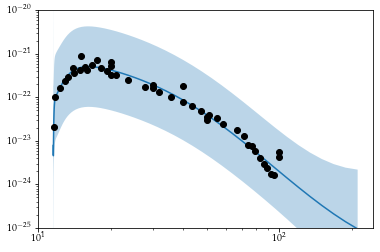

In [154]:
# ax = krig.plot()
plt.figure(1)
plt.loglog(np.exp(gridx)+E1,np.exp(krig.field),'-')
plt.scatter(np.exp(Wn[:,0])+E1, np.exp(Wn[:,1]), color="k", zorder=10, label="Conditions")
plt.fill_between(
    np.exp(gridx)+E1,
    # plus/minus standard deviation (70 percent confidence interval)
    np.exp(krig.field - 3*np.sqrt(krig.krige_var)),
    np.exp(krig.field + 3*np.sqrt(krig.krige_var)),
    alpha=0.3,
    label="Standard deviation",
)
ax.legend()
plt.xscale('log')
plt.yscale('log')
plt.ylim([1e-25, 1e-20])
# plt.xlim(np.exp([min(Wn[:,0])-fit_model.len_scale, max(Wn[:,0])+fit_model.len_scale]))

krig_data = np.array([gridx,krig.field,np.sqrt(krig.krige_var)])
filename = '../crs-exp/excitation-level1/crs.krig.txt'
np.savetxt(filename,krig_data.T,fmt='%.15E',delimiter=' ')

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
Tsurubuchi, S., Miyazaki, T., & Motohashi, K. (1996). Electron-impact emission cross sections of Ar. Journal of Physics B: Atomic, Molecular and Optical Physics, 29(9), 1785–1801. https://doi.org/10.1088/0953-4075/29/9/022
11.828


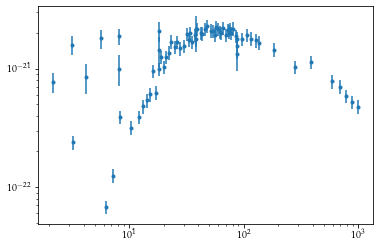

In [4]:
dataType = crs.typeDictS2I['Excitation, level 4']

# W = [[]]
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        print(swarm.ref)
        temp = np.copy(swarm.datasets[dataType].data)
        var1 = swarm.datasets[dataType].variables[1]

        if ( swarm.variables[var1][0] == 'cm2' ):
            temp[:,1] *= 1e-4
            
        if (swarm.variables[var1][1]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        elif (swarm.variables[var1][2]!='n/a'):
            error = temp[:,1][...,None] * 1e-2 / 3.0 * crs.readNumber(swarm.variables[var1][1][:-1])
            temp = np.append( temp, error, axis=1)
        else:
            if (len(swarm.datasets[dataType].variables)<3):
                # assume 50% standard deviation
                error = temp[:,1][...,None] * 0.5
                temp = np.append( temp, error, axis=1)
            else:
                var2 = swarm.datasets[dataType].variables[2]
                if ( swarm.variables[var2][0] == '%' ):
                    temp[:,2] *= 1e-2 * temp[:,1]
                elif ( swarm.variables[var2][0] == 'cm2' ):
                    temp[:,2] *= 1e-4
                if ( var2[-3:] == 'max' ):
    #                 temp[:,2] *= 1.0
                    temp[:,2] *= 1.0 / 3.0
                
        if (k==0):
            W = np.copy(temp)
        else:
            W = np.append( W, temp, axis=0)

        filename = '../crs-exp/excitation-level4/crs.%s.txt' % (refs[k])
        np.savetxt(filename,temp,fmt='%.15E',delimiter=' ')
    
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.5
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
#         W += [temp]
#         W = np.append( W, temp, axis=0)
    
# E1 = 11.624
E1 = 11.828
plt.figure(1)
plt.errorbar(W[:,0]-E1,W[:,1],yerr=W[:,2],fmt='.')
plt.xscale('log')
plt.yscale('log')

(72, 3)
{'var': 1.1728272040230827, 'len_scale': 1.7000164077820308, 'nugget': 0.10055641793478635}


/opt/homebrew/lib/python3.9/site-packages/gstools/covmodel/plot.py:112: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


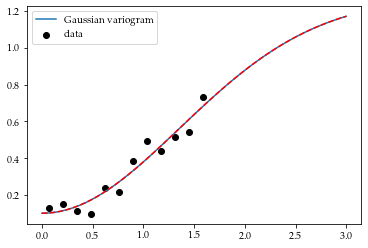

In [6]:
import gstools as gs

Wn = np.copy(W)
E1 = 11.828
Wn[:,0] = np.log(Wn[:,0] - E1)
Wn[:,2] = np.log( 1.0 + Wn[:,2]/Wn[:,1] )
Wn[:,1] = np.log(Wn[:,1])
print(Wn.shape)

bins = gs.variogram.standard_bins(Wn[:,0])
bin_center, gamma = gs.vario_estimate(Wn[:,0],Wn[:,1],bin_edges=bins)

models = {
    "Gaussian": gs.Gaussian,
    "Exponential": gs.Exponential,
    "Matern": gs.Matern,
    "Stable": gs.Stable,
    "Rational": gs.Rational,
    "Circular": gs.Circular,
    "Spherical": gs.Spherical,
    "SuperSpherical": gs.SuperSpherical,
    "JBessel": gs.JBessel,
}
scores = {}

# plot the estimated variogram
plt.scatter(bin_center, gamma, color="k", label="data")
ax = plt.gca()

# fit all models to the estimated variogram
# for modelType in models:
modelType = "Gaussian"
fit_model = models[modelType](dim=1)
# fit_model.set_arg_bounds(nugget=[1.0,5.0],len_scale=[0.,3.])
para, pcov, r2 = fit_model.fit_variogram(bin_center, gamma, return_r2=True)
# fit_model.plot(x_max=1, ax=ax)
scores[modelType] = r2
    
print(para)
# fit_model.nugget = 1.0
# fit_model.var *= 0.9
# fit_model.len_scale -= 0.02
para['nugget'] = fit_model.nugget
para['var'] = fit_model.var
fit_model.plot(x_max=3, ax=ax)
model = models[modelType](dim=1, **para)

r = np.linspace(0.,3.0,51)
Z = fit_model.variogram(r)
plt.plot(r,Z,'--r');

# filename = '../crs-exp/excitation-level2/krig.variogram.model.txt'
# np.savetxt(filename,np.array([r,Z]).T,fmt='%.15E',delimiter=' ')
# filename = '../crs-exp/excitation-level2/krig.variogram.empirical.txt'
# np.savetxt(filename,np.array([bin_center,gamma]).T,fmt='%.15E',delimiter=' ')

In [9]:
krig = gs.Krige(
    model=model,
    cond_pos=Wn[:,0],
    cond_val=Wn[:,1],
#     mean=1,
#     unbiased=False,
    exact=False,
    cond_err=Wn[:,2],
)

# resulting grid
gridx = np.linspace(np.log(2e0), np.log(2e3), 101)
krig(gridx)

mask = np.exp(gridx) < 20.0
krig.krige_var[mask] *= 16.

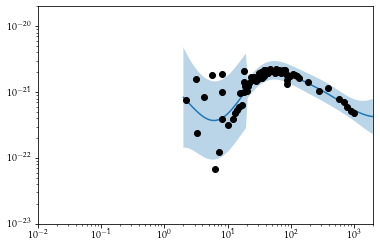

In [10]:


# ax = krig.plot()
plt.figure(1)
# plt.plot(gridx,krig.field,'-')
# plt.scatter(Wn[:,0], Wn[:,1], color="k", zorder=10, label="Conditions")
# plt.fill_between(
#     gridx,
#     # plus/minus standard deviation (70 percent confidence interval)
#     krig.field - 3*np.sqrt(krig.krige_var),
#     krig.field + 3*np.sqrt(krig.krige_var),
#     alpha=0.3,
#     label="Standard deviation",
# )
plt.loglog(np.exp(gridx),np.exp(krig.field),'-')
plt.scatter(np.exp(Wn[:,0]), np.exp(Wn[:,1]), color="k", zorder=10, label="Conditions")
plt.fill_between(
    np.exp(gridx),
    # plus/minus standard deviation (70 percent confidence interval)
    np.exp(krig.field - 1*np.sqrt(krig.krige_var)),
    np.exp(krig.field + 1*np.sqrt(krig.krige_var)),
    alpha=0.3,
    label="Standard deviation",
)
ax.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e-2, 2e3])
plt.ylim([1e-23, 2e-20])
# plt.xlim(np.exp([min(Wn[:,0])-fit_model.len_scale, max(Wn[:,0])+fit_model.len_scale]))

krig_data = np.array([gridx,krig.field,np.sqrt(krig.krige_var)])
filename = '../crs-exp/excitation-level4/crs.krig.txt'
np.savetxt(filename,krig_data.T,fmt='%.15E',delimiter=' ')